In [1]:
%load_ext autoreload
%autoreload 2

In [17]:
from ariel_pred.dataset import DataLoaderAndCalibrator
from ariel_pred.preprocessing import SGSmoothing
from ariel_pred.plots import plot_white_curve
from ariel_pred.transit import FunctionFittingBasedPhaseDetector
from ariel_pred.features import WavelengthsGroupsMultiplierFinder
from ariel_pred.modeling.cnn_spectrum_only import OnlySpectrumFromSValuesCNN
from ariel_pred.metrics import score, gll
from ariel_pred.sigma import SpectrumVariationScaler
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import random
from scipy.optimize import minimize
from tqdm.auto import tqdm
import pandas as pd
import torch
from torch import nn

In [3]:
data_loader = DataLoaderAndCalibrator(
    data_path=Path("../data/raw"),
    output_path=Path("../data/calibrated/full"),
    force_recalibration=False,
    cut_airs_channels=True,
    binning=4,
    n_jobs=4
)
train_data, train_labels = data_loader.load_all_train_data()
train_data.shape, train_labels.shape

Loading calibrated train data...


((1100, 1406, 283), (1100, 283))

In [4]:
features_extractor = WavelengthsGroupsMultiplierFinder()

features = features_extractor.extract_features(
    train_data,
    average_cross_groups=False,
    wavelengths_groups=[1, 2, 4, 8, 16, 32, 64],
    weights=[1, 1, 1, 1, 1, 1, 1]
)

features.shape

100%|██████████| 1100/1100 [05:41<00:00,  3.22it/s]


(1100, 283, 7)

In [5]:
cnn_train_data = features.transpose(0, 2,1)
cnn_train_data.shape

(1100, 7, 283)

In [35]:
features.min(), features.max()

(np.float64(-0.006127139654034788), np.float64(0.10331617710565856))

In [ ]:
trainer = OnlySpectrumFromSValuesCNN(
    Path("../models/spectrum_only_s_values_cnn"),
    device=torch.device("mps"),
    in_channels=cnn_train_data.shape[1],
    num_channels=283,
    train_multiplier=1.0
)

res = trainer.train(cnn_train_data, train_labels, n_splits=5, return_predictions=True)

if res is not None:
    spectrum, (val_rmse, val_loss, train_loss) = res # type: ignore
    np.save("../models/spectrum_only_s_values_cnn/val_spectrum.npy", spectrum)
else:
    spectrum = np.load("../models/spectrum_only_s_values_cnn/val_spectrum.npy")

No saved models found in the specified path. Starting training from scratch.


Training Model:   0%|          | 0/1000 [00:00<?, ?it/s]

In [9]:
np.sqrt(np.mean((spectrum - train_labels) ** 2)), np.mean(np.abs(spectrum - train_labels))

(np.float64(0.0007364477734727713), np.float64(0.00041203847919248993))

In [12]:
np.sqrt(np.mean((0.945*features.mean(axis=2) - train_labels) ** 2)), np.mean(np.abs(0.945*features.mean(axis=2) - train_labels))

(np.float64(0.0007461554133075029), np.float64(0.0004070589734051623))

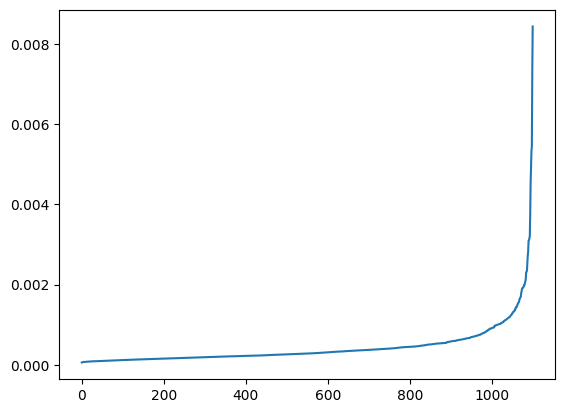

In [15]:
per_planet_rmse = np.sqrt(np.mean((spectrum - train_labels) ** 2, axis=1))

plt.plot(np.sort(per_planet_rmse))

In [16]:
per_planet_rmse.mean(), per_planet_rmse.std()

(np.float64(0.00044099988379009777), np.float64(0.0005898088042324584))

In [26]:
sigma_calculator = SpectrumVariationScaler(mean_sigma=8.5e-4, num_channels=283)
predicted_sigma = sigma_calculator.get_sigma(spectrum)
gll(np.concatenate([spectrum, predicted_sigma], axis=1), train_labels)

0.3704459549984901

In [27]:
gll(np.concatenate([spectrum, np.ones_like(spectrum) * 8.5e-4], axis=1), train_labels)

0.3325609121583659

In [ ]:
np.percentile(per_planet_rmse, 90)

np.float64(0.0008503586727299302)

In [30]:
per_planet_rmse.mean()

np.float64(0.00044099988379009777)

In [34]:
np.sqrt(np.mean(((0.95*features).mean(axis=2) - train_labels) ** 2, axis=1)).mean()

np.float64(0.00043539277930740755)

In [ ]:
negative_indices = np.where(features < 0)
negative_indices

(array([ 89,  89,  89,  89, 242, 242, 242, 242, 242, 242, 242, 242, 242,
        242, 242, 242, 289, 289, 289, 289, 496, 496, 496, 496, 634, 634,
        634, 634, 707, 707, 707, 707, 804, 804, 804, 804, 818, 818, 818,
        818]),
 array([275, 276, 277, 278, 275, 275, 276, 276, 277, 277, 278, 278, 279,
        280, 281, 282, 183, 184, 185, 186, 263, 264, 265, 266, 259, 260,
        261, 262, 279, 280, 281, 282, 279, 280, 281, 282, 271, 272, 273,
        274]),
 array([6, 6, 6, 6, 5, 6, 5, 6, 5, 6, 5, 6, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6,
        6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6]))

In [49]:
np.sqrt(((np.array([spectrum[i, j] for i, j, k in zip(*negative_indices)]) - np.array([train_labels[i, j] for i, j, k in zip(*negative_indices)])) ** 2).mean())

np.float64(0.0030620107589279075)

In [50]:
positive_indices = np.where(features >= 0)
np.sqrt(((np.array([spectrum[i, j] for i, j, k in zip(*positive_indices)]) - np.array([train_labels[i, j] for i, j, k in zip(*positive_indices)])) ** 2).mean())

np.float64(0.0007363376736006467)